In [1]:
import datetime
from phd_clouds.clouds import CloudProcessing
import matplotlib.pyplot as plt
from pdb import set_trace
import pandas as pd
import calendar
import numpy as np
import xarray as xr
import os
from multiprocessing import Pool, cpu_count
from tqdm import tqdm


In [27]:
%matplotlib inline
# %matplotlib widget
# Define here plot configuration
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 14
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 1
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['axes.titlepad'] = 20  # Raise title
# sans serif
# plt.rcParams['font.family'] = 'serif'
# plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

In [3]:
PATH_FIG     = '../../tests/figures/'
path_save = "/media/matheustolen/Seagate Basic/cloud-statistics-data/products/cloud_classification" # Path to save the cloud classification files
path_microphys = "/home/matheustolen/Documentos/matheus_doctorado/output_retrievals" # Path with files already downloaded
path_categorize = "/media/matheustolen/Seagate Basic/cloud-statistics-data/categorize" # Path with files already downloaded
path_radar = "/media/matheustolen/Seagate Basic/cloud-statistics-data/radar" # Path with files already downloaded
path_classification = "/media/matheustolen/Seagate Basic/cloud-statistics-data/classification" # Path with files already downloaded
path_mwr = "/media/matheustolen/Seagate Basic/cloud-statistics-data/mwr" # Path with files already downloaded
path_sensitivity = "/media/matheustolen/Seagate Basic/cloud-statistics-data/sensitivity_analysis" # Path to save the sensitivity analysis files

# User defined thresholds for cluster classification
## Usefull for sensitivity analysis

In [15]:
def process_single_date(
    datastr,
    site,
    path_classification,
    path_categorize,
    path_radar,
    path_mwr,
    list_vars,
    dic_threshold,
    props_to_analyse,
    cloud_occur_vars,
    cloud_type_vars,
    folder_names,
    cloud_cmap,
):
    try:
        # Create a fresh CloudProcessing instance per process
        cloud_processing = CloudProcessing(
            path_classification=path_classification,
            path_microphys=path_microphys,
            path_categorize=path_categorize,
            path_radar=path_radar,
            path_mwr=path_mwr,
            site=site
        )

        # -----------------------------
        # The rest of your per-date code
        # -----------------------------
        cloud_processing.get_filenames_from_datastr(datastr)

        if not cloud_processing.filenames['classification']:
            print(f"[{datastr}] Classification not found. Skipping.")
            return datastr

        cloud_processing.load_classification()
        cloud_processing.load_categorize()
        cloud_processing.load_lwc_scaled_adiabatic()
        cloud_processing.load_iwc_Z_T_method()
        cloud_processing.load_radar()
        cloud_processing.load_mwr()
        cloud_processing.initialize_time()
        cloud_processing.initialize_datasets()
        cloud_processing.add_radar_lwp()
        cloud_processing.add_mwr_lwp()
        cloud_processing.calculate_fit_parameters(small_than=0.2, larger_than=0.8)
        cloud_processing.create_count_dataset_for_verification()
        cloud_processing.plot_linear_fit_lwp(make_plot=False)
        cloud_processing.generate_cloud_mask()

        for var in list_vars:

            ds_cloud_props_sensitivity = xr.Dataset(
                coords={"time": cloud_processing.time, var: dic_threshold[var]},
                data_vars={
                    prop: (("time", var),
                           np.full((len(cloud_processing.time), len(dic_threshold[var])), np.nan))
                    for prop in props_to_analyse
                }
            )

            ds_cloud_occur_sensitivity = xr.Dataset(
                coords={"time": cloud_processing.time, var: dic_threshold[var]},
                data_vars={
                    prop: (("time", var),
                           np.full((len(cloud_processing.time), len(dic_threshold[var])), np.nan))
                    for prop in cloud_occur_vars
                }
            )

            ds_cloud_type_sensitivity = xr.Dataset(
                coords={"time": cloud_processing.time, var: dic_threshold[var]},
                data_vars={
                    prop: (("time", var),
                           np.full((len(cloud_processing.time), len(dic_threshold[var])), np.nan))
                    for prop in cloud_type_vars
                }
            )

            for threshold in dic_threshold[var]:
                cloud_processing.classify_clusters_user_defined_thresholds(**{var: threshold})
                cloud_processing.analyze_clouds(
                    filter_abl_ice_clouds=True,
                    thick_threshold=700,
                    base_threshold=4000
                )
                cloud_processing.create_cluster_classification_product()
                cloud_processing.create_attenuation_mask(
                    cloud_cmap,
                    time_roll="10T",
                    lwp_treshold=0.8,
                    corr_treshold=-.5,
                    lwp2_treshold=1,
                    make_plot=True
                )
                
                cloud_processing.add_attenuation_to_clouds()
                cloud_processing.compute_cloud_lwp_iwp(make_plot=True)

                for prop in props_to_analyse:
                    ds_cloud_props_sensitivity[prop].loc[:, threshold] = cloud_processing.cloud_props[prop]

                for prop in cloud_occur_vars:
                    ds_cloud_occur_sensitivity[prop].loc[:, threshold] = cloud_processing.cloud_occurrence[prop]

                for prop in cloud_type_vars:
                    ds_cloud_type_sensitivity[prop].loc[:, threshold] = cloud_processing.cloud_type[prop]

            date_str = cloud_processing.time[0].dt.strftime('%Y%m%d').values.item()

            # for fname in folder_names:
            #     dir_path = os.path.join(path_sensitivity, fname)
            #     os.makedirs(dir_path, exist_ok=True)

            #     if fname == "cloud_properties":
            #         ds_cloud_props_sensitivity.to_netcdf(
            #             os.path.join(dir_path, f"{date_str}_cloud_props_sensitivity_{var}.nc")
            #         )
            #     elif fname == "cloud_occurrence":
            #         ds_cloud_occur_sensitivity.to_netcdf(
            #             os.path.join(dir_path, f"{date_str}_cloud_occur_sensitivity_{var}.nc")
            #         )
            #     elif fname == "cloud_type":
            #         ds_cloud_type_sensitivity.to_netcdf(
            #             os.path.join(dir_path, f"{date_str}_cloud_type_sensitivity_{var}.nc")
            #         )

        print(f"[{datastr}] DONE")

    except Exception as e:
        print(f"[{datastr}] FAILED: {e}")


In [32]:

run_parallel = False  # <-- set to False for serial execution

list_cloud_colors = ["#FFFFFF", "#007CFF", "blue", "cyan", "grey", "yellow", "orange", "magenta"]
cloud_cmap = plt.cm.colors.ListedColormap(list_cloud_colors)

products_to_save = {
    "cloud_occurrence": False,
    "cloud_props": False,
    "cloud_type": False,
    "fit_params": False,
    "count_verification": False,
}

dn = 20
dp = 5

dic_threshold = {
    'min_cloudp': np.array([10]),
    'min_rainp': np.arange(0, 20 + 5, 5),
    'min_liquid_percentage': np.arange(50, 100 + 5, 5),
    'min_ice_percentage': np.arange(60, 100 + dp, dp)
}

# dic_threshold = {
#     'min_cloudp': np.arange(0, 150 + 20, 20),
#     'min_rainp': np.arange(0, 20 + 5, 5),
#     'min_liquid_percentage': np.arange(50, 100 + 5, 5),
#     'min_ice_percentage': np.arange(60, 100 + dp, dp)
# }

site             = 'granada'
list_vars        = ['min_cloudp', 
                    # 'min_rainp', 
                    # 'min_liquid_percentage', 
                    # 'min_ice_percentage',
                    ]
 
props_to_analyse = ['cloud_base', 'cloud_thickness', 'cloud_lwp', 'cloud_iwp']
cloud_occur_vars = ['single_layer', 'multi_layer', 'clear_sky', 'noise', 'attenuation']
cloud_type_vars  = ['Liquid', 'Precipitating-Liquid', 'Ice', 'Precipitating-Ice', 'Mixed-Phase', 'Precipitating-Mixed-Phase', 'Not Classified']
folder_names     = ['cloud_properties', 'cloud_occurrence', 'cloud_type']

date_ini = datetime.datetime(2021, 12, 22) # 2018-04-22
date_end = datetime.datetime(2021, 12, 22) # 2023-12-31

date_list = [datetime.datetime.strftime(date, "%Y%m%d") for date in pd.date_range(date_ini.strftime("%Y-%m-%d"), date_end.strftime("%Y-%m-%d"), freq='1D')]

args_list = [
    (
        datastr,
        site,
        path_classification,
        path_categorize,
        path_radar,
        path_mwr,
        list_vars,
        dic_threshold,
        props_to_analyse,
        cloud_occur_vars,
        cloud_type_vars,
        folder_names,
        cloud_cmap
    )
    for datastr in date_list
]

Running serially
Fit parameters are not available. It does not interfere in the attenuation mask, where we use the radar LWP.


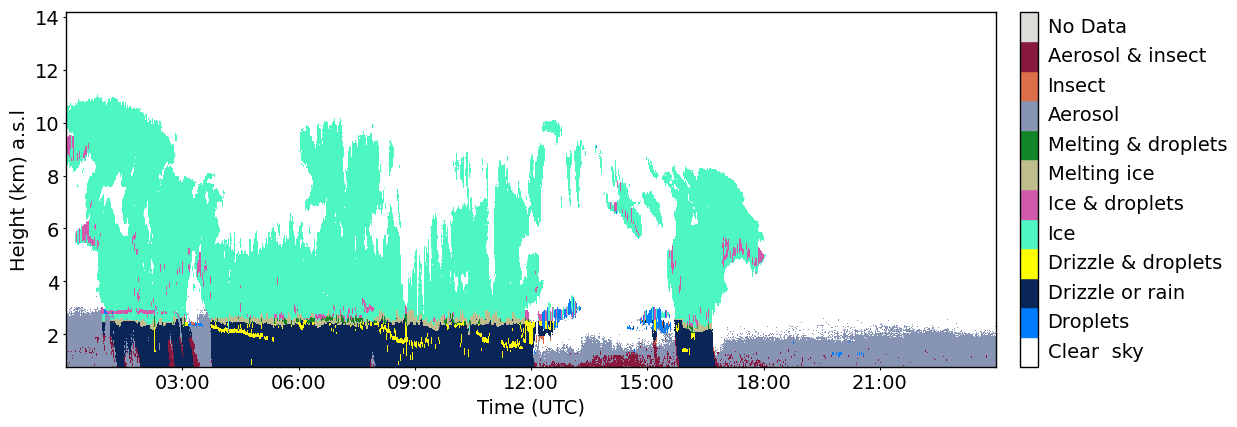

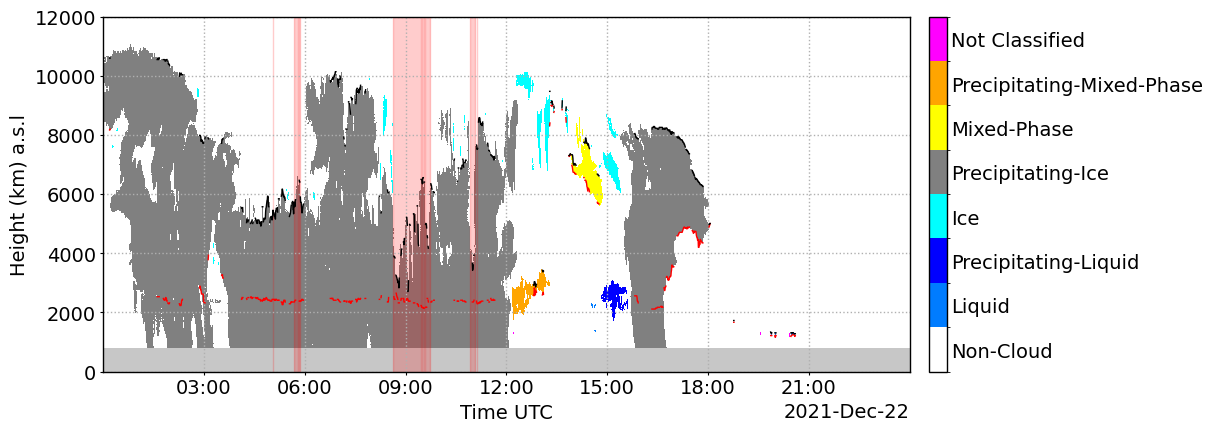

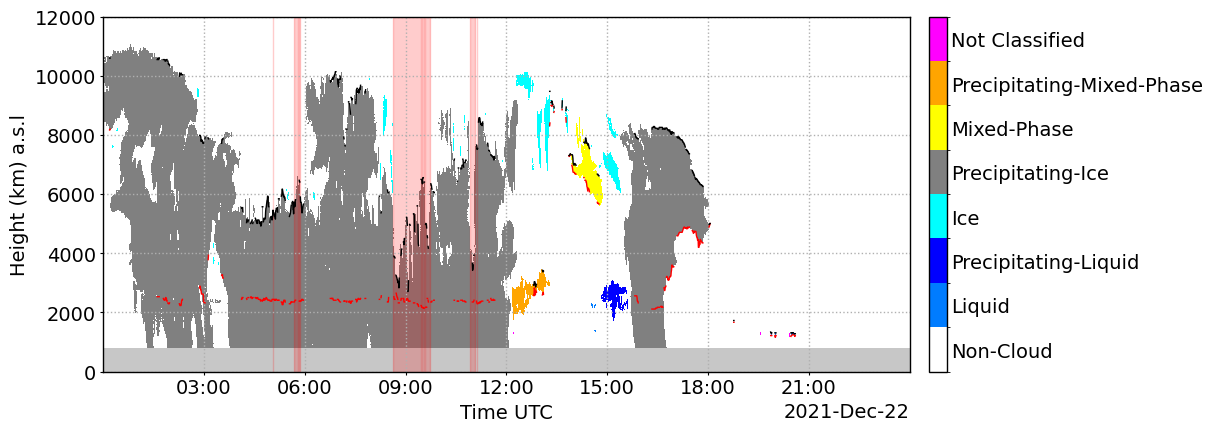

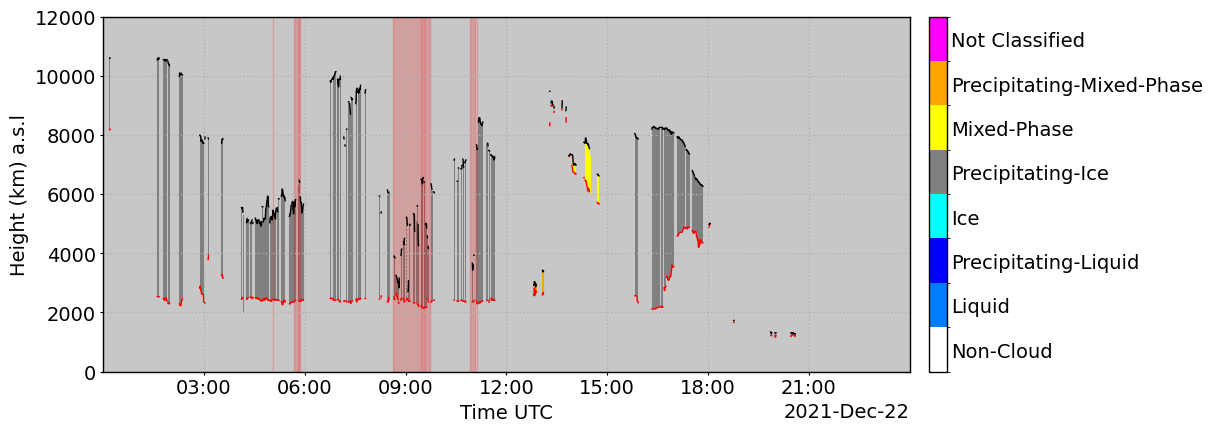

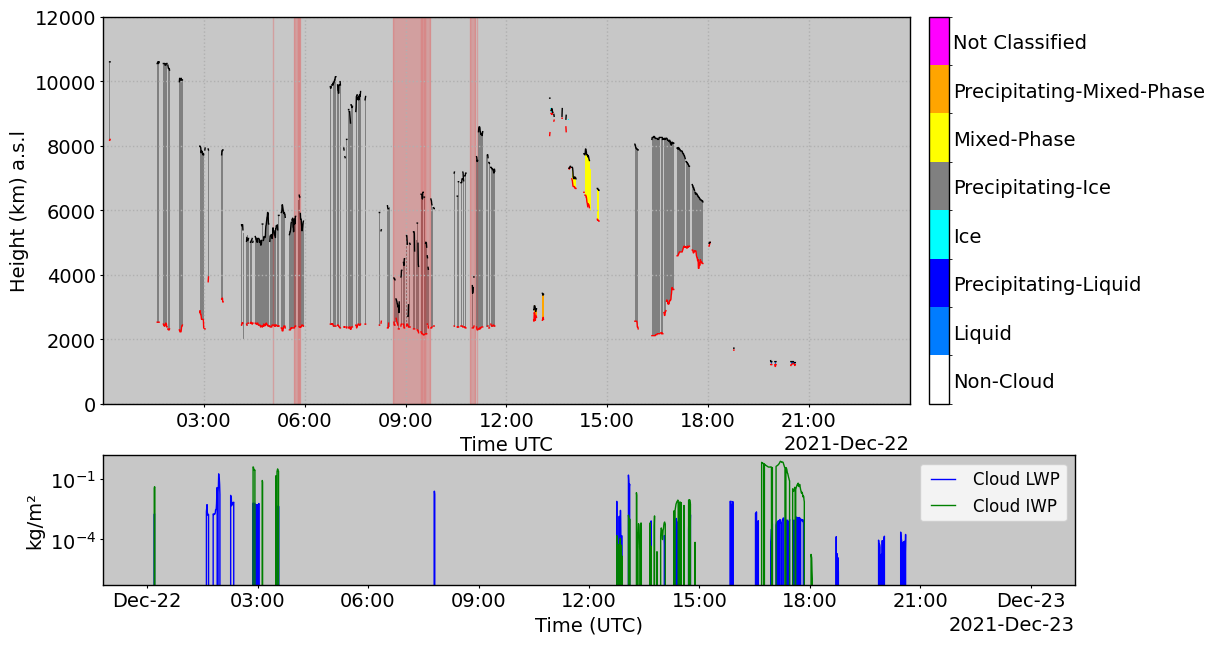

[20211222] DONE


In [33]:
plt.close('all')
if run_parallel:

    n_workers = min(cpu_count(), 8)
    print(f"Running in parallel with {n_workers} workers")

    with Pool(processes=n_workers) as pool:
        pool.starmap(process_single_date, args_list)

else:
    print("Running serially")
    for args in args_list:
        process_single_date(*args)